### __Regularisation - Ridge__

Picture a regression model that scores brilliantly on your training data, then falls apart the moment it sees new examples. That gap, low training error and high test error, is __overfitting__, and it happens when a model has learned the noise in your data instead of the real pattern. __Ridge regression__ addresses this by adding an __L2 penalty__ that keeps coefficients small, nudging the model toward simpler, more general solutions. In this video, you will see exactly how that penalty works and how to implement ridge regression in code.

**By the end of this lesson, you should be able to:**

- Implement __ridge regression__ in Python and fit it to a dataset
- Explain how the __L2 penalty__ shrinks coefficients and reduces overfitting compared to standard linear regression
- Observe how changing regularization strength, or __lambda/alpha__, shifts the __bias-variance trade-off__
- Compare __train error__ and test error to judge whether your model is generalizing well

### __Regularisation in 5 minutes__

Regularisation is like having a magic wand to make our predictions better in a smarter way.

Imagine we're baking a cake and we have a bunch of ingredients. Each ingredient (like flour, eggs, sugar) affects how the cake turns out. Similarly, in making predictions, we have different factors, or "ingredients", that affect our predictions.

Now, think of each ingredient as having its own importance level. For instance, in baking, maybe we need more flour than sugar. Similarly, in predicting, some factors might be more important than others.

In the past, we used to pick and choose which ingredients to use in our recipes. But with regularisation, we keep all the ingredients but adjust their amounts based on how important they are.

Let's take a look at our recipe, or equation, for making predictions:

$$RSS = \sum_{i=1}^n(y_i-(a+\sum_{j=1}^pb_jx_{ij}))^2$$

This might look like a complicated recipe, but it's just a way of saying, "Let's see how well our predictions match up with reality."

Now, here's the cool part. Regularisation adds a little twist to our recipe. It says, "Hey, let's not let any ingredient (or factor) get too big." Why? Because when one ingredient becomes too dominant, it can mess up the taste of our cake (or the accuracy of our predictions).

So, we add a new rule to our recipe:

$$\sum_{i=1}^n(y_i-(a+\sum_{j=1}^pb_jx_{ij}))^2 + \alpha\sum_{j=1}^pb_j^2$$

The new part, $\alpha\sum_{j=1}^pb_j^2$, is like a secret sauce that helps us control the quantities of our ingredients. The $\alpha$ is like a knob we can turn to decide how much we want to control the sizes.

Imagine $\alpha$ as the volume control on your music player. If you turn it up, it makes the ingredients smaller. If you turn it down, it lets them be bigger.

This secret sauce helps us balance two things: making sure our predictions fit the real data well, but also making sure none of our ingredients (or factors) become too overwhelming.

![tradeoff](https://raw.githubusercontent.com/Explore-AI/Pictures/master/tradeoff.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from styleplot import style_plot

In [2]:
df = pd.read_csv("SDG_15_Life_on_Land_Dataset.csv")
df.head()

,WaterQualityIndex,ClimateChangeImpactScore,LandUseChange,InvasiveSpeciesCount,ConservationFunding,EcoTourismImpact,ForestCoverChange,SoilQualityIndex,WaterUsage,RenewableEnergyUsage,CarbonEmissionLevels,AgriculturalIntensity,HabitatConnectivity,SpeciesReintroductionEfforts,PollinatorDiversity,BiodiversityHealthIndex
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795
3,36,7.060190,7.061932,37,88,9.718453,3.425382,64,85,96,60,1.065595,4.938359,2.192657,0.145065,0.926146
4,24,8.439246,4.504786,41,88,9.118186,-1.295086,12,0,85,61,9.785784,2.114002,7.405189,0.809798,0.126345


In [4]:
import re

df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df.columns
]

df.head(3)

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity,biodiversity_health_index
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795


In [5]:
print(df.shape)

(1000, 16)


In [6]:
print(df.columns)

Index(['water_quality_index', 'climate_change_impact_score', 'land_use_change',
       'invasive_species_count', 'conservation_funding', 'eco_tourism_impact',
       'forest_cover_change', 'soil_quality_index', 'water_usage',
       'renewable_energy_usage', 'carbon_emission_levels',
       'agricultural_intensity', 'habitat_connectivity',
       'species_reintroduction_efforts', 'pollinator_diversity',
       'biodiversity_health_index'],
      dtype='str')


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   water_quality_index             1000 non-null   int64  
 1   climate_change_impact_score     1000 non-null   float64
 2   land_use_change                 1000 non-null   float64
 3   invasive_species_count          1000 non-null   int64  
 4   conservation_funding            1000 non-null   int64  
 5   eco_tourism_impact              1000 non-null   float64
 6   forest_cover_change             1000 non-null   float64
 7   soil_quality_index              1000 non-null   int64  
 8   water_usage                     1000 non-null   int64  
 9   renewable_energy_usage          1000 non-null   int64  
 10  carbon_emission_levels          1000 non-null   int64  
 11  agricultural_intensity          1000 non-null   float64
 12  habitat_connectivity            1000 non-null 

Our dataset contains various environmental indicators related to SDG 15, such as deforestation rates, protected area coverage, biodiversity indices, and other relevant variables. Our objective is to model an environmental outcome for  the health of biodiversity using these indicators.

The mathematical representation of our model can be described as follows:

$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p$$

In this formulation, $Y$ represents the response variable, which in our case is `BiodiversityHealthIndex`. This response variable is influenced by _p_ predictor variables ($X_1, X_2, ..., X_p$), each representing different environmental indicators relevant to SDG 15.

### __Review of data scaling__

Data scaling is a key step when preparing our data for a model, especially when using techniques like regularisation. Regularisation helps improve our model by not letting it rely too much on any single feature, and it does this by keeping the model's coefficients (essentially, the importance it assigns to each feature) in check. But here's the catch: the size of these coefficients can be influenced by two main things:

1. **How strongly a feature (let's call it `x`) is connected to the outcome (or `y`)**. This is the kind of relationship we're interested in capturing because it tells us something meaningful about our data.
2. **The scale of the feature values**. For instance, imagine we're measuring distance. If we switch from metres to kilometres, the numbers change drastically, even though we're talking about the same distances. This change can unfairly affect the size of the coefficients.

We want our model to focus on the real relationships in the data, not get thrown off by how we happen to measure things. That's where data scaling comes in. It adjusts the features so they're on a similar scale, making it easier for our regularisation technique to do its job properly.

A popular method for scaling is called **Z-score standardisation**. It tweaks our data so that the features have similar ranges, and it's smart enough to handle outliers (data points that are very different from the rest) gracefully. Let's put this into action by using standard scaling in our model.

To do this, we'll use something called `StandardScaler()` from a library in Python known as `sklearn.preprocessing`.

In [8]:
# split data into predictors and response
X = df.drop('biodiversity_health_index', axis=1)
y = df['biodiversity_health_index']

In [13]:
# import scaler method from sklearn
from sklearn.preprocessing import StandardScaler

# Import train/test splitting function from sklearn
from sklearn.model_selection import train_test_split

# Import the ridge regression module from sklearn
from sklearn.linear_model import Ridge

In [10]:
# create scaler object
scaler = StandardScaler()

In [11]:
# create scaled version of the predictors (there is no need to scale the response)
X_scaled = scaler.fit_transform(X)

In [30]:
# convert the scaled predictor values into a DataFrame
X_standardised = pd.DataFrame(X_scaled,columns=X.columns)
X_standardised.head()

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity
0,-0.509823,0.915895,0.532798,0.967295,-0.129430,-1.297085,0.017923,0.689812,-0.641157,-1.290990,-0.930835,-1.237558,-1.131411,1.494660,-0.811078
1,-1.261473,-1.159761,0.479063,1.382383,-1.098165,1.226669,-1.649745,0.655167,0.539995,0.207271,0.470716,-0.670150,0.305779,-0.107952,0.797582
2,-1.363971,-1.409483,1.389846,0.206299,0.320340,-0.529103,-0.877370,0.759101,1.165311,-0.473757,-0.110415,1.006319,1.598836,-1.017291,-1.518029
3,-0.475658,0.746916,0.684528,0.828932,1.323673,1.653728,1.188117,0.481943,1.165311,1.535274,0.368164,-1.360736,0.001642,-0.978326,-1.249998
4,-0.885648,1.230038,-0.213905,1.105658,1.323673,1.445945,-0.439815,-1.319584,-1.787570,1.160709,0.402348,1.675792,-0.977884,0.832482,1.077254


### __Ridge regression__

For our analysis, we'll start by dividing our dataset into a training set and a testing set. Unlike time-series data where the chronological order is crucial, our dataset consists of independent observations related to various environmental factors. Therefore, we can randomly sample rows for the training and testing sets without worrying about their order.

After splitting our dataset, we'll proceed to fit and evaluate our model. Initially, we'll create a `Ridge()` object using the default parameter settings, which means we'll start with an $\\alpha$ value of 1. This alpha parameter controls the strength of the regularisation applied to our model, with higher values leading to more significant regularisation. In a later tutorial, we'll learn about choosing a better value for this hyperparameter.

In [31]:
# Split the data into train and test, being sure to use the standardised predictors
X_train, X_test, y_train, y_test = train_test_split(
    X_standardised, y, test_size = 0.2, random_state=42,
    shuffle=True
)

In [32]:
# Create ridge model with alpha = 1
ridge = Ridge(alpha=1)

In [33]:
# Train the model
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [34]:
# Extract the model intercept value
b0 = float(ridge.intercept_)

In [35]:
# Extract the model coefficient value
coeff = pd.DataFrame(ridge.coef_, X.columns, columns=['Coefficient'])

In [36]:
print("Intercept:", float(b0))

Intercept: 0.5041247356396944


In [38]:
# Check out the coefficients
coeff

,Coefficient
water_quality_index,0.013383
climate_change_impact_score,-0.006674
land_use_change,0.014061
invasive_species_count,0.012683
conservation_funding,-0.023633
eco_tourism_impact,-0.021419
forest_cover_change,-0.017862
soil_quality_index,-0.000488
water_usage,0.000742
renewable_energy_usage,-0.001486


### __Interpretation of the intercept and coefficients__

Since we've standardised the features in our dataset, we're now able to directly compare the coefficients with one another. This is because all the variables are scaled to the same unit. The intercept in our model represents the expected health of biodiversity when all the features (like deforestation rate, pollution levels, conservation funding, etc.) are at their average values. The coefficients tell us how the Biodiversity Health Index is expected to change with a one-unit increase in each **scaled feature value**.

Variables with smaller coefficients can be seen as having a lesser impact on biodiversity health; they've been more heavily penalised in the regularisation process, suggesting they're less crucial in predicting biodiversity health in our model.

### __Assess the predictive accuracy of the model__

To evaluate how well our model predicts biodiversity health, we can use tools from the `sklearn.metrics` library. To see the effectiveness of regularisation, we'll also compare our results to a basic linear model that doesn't use regularisation. This comparison will help us understand the benefits of applying regularisation to our environmental conservation dataset.

In [39]:
# Fit a basic linear model
from sklearn.linear_model import LinearRegression

# Import metrics module
from sklearn import metrics

In [40]:
# Create model object
lm = LinearRegression()

# Train model
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0.01,-0.01, 0.01,...,-0. , 0.01,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['water_quality_index','climate_change_impact_score','land_use_change',..., 'habitat_connectivity','species_reintroduction_efforts', 'pollinator_diversity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5041
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


In [41]:
# Check training accuracy
train_lm = lm.predict(X_train)
train_ridge = ridge.predict(X_train)

print('Training MSE')
print('Linear:', metrics.mean_squared_error(y_train, train_lm))
print('Ridge :', metrics.mean_squared_error(y_train, train_ridge))

Training MSE
Linear: 0.08002774365644137
Ridge : 0.0800277471143878


In [42]:
test_lm = lm.predict(X_test)
test_ridge = ridge.predict(X_test)

print('Testing MSE')
print('Linear:', metrics.mean_squared_error(y_test, test_lm))
print('Ridge :', metrics.mean_squared_error(y_test, test_ridge))

Testing MSE
Linear: 0.08769915106362262
Ridge : 0.08769125246152339


The increase in training MSE is not anything to be worried about since we want to avoid overfitting on the training set. However, the MSE values need to be contextualised to understand the model's performance better. The magnitude of the MSE can be influenced by the scale of the data and the choice of the predictive variable. Thus, it is crucial to consider these factors when assessing the model's accuracy.

As a final step, let's plot our results.

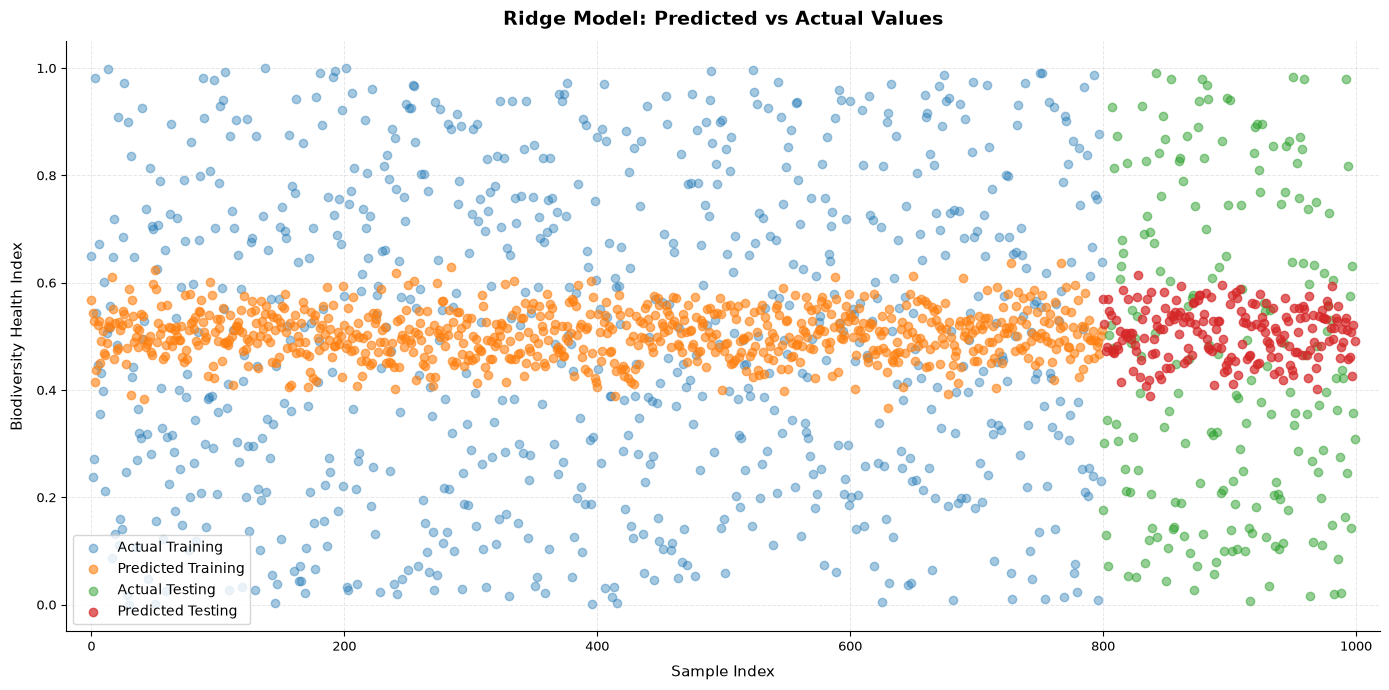

In [43]:
# Predictions
y_pred_train = ridge.predict(X_standardised.iloc[:len(y_train)])
y_pred_test = ridge.predict(X_standardised.iloc[len(y_train):])

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Training data
ax.scatter(
    np.arange(len(y_train)),
    y_train,
    label="Actual Training",
    alpha=0.4
)

ax.scatter(
    np.arange(len(y_train)),
    y_pred_train,
    label="Predicted Training",
    alpha=0.6
)

# Testing data
ax.scatter(
    np.arange(len(y_test)) + len(y_train),
    y_test,
    label="Actual Testing",
    alpha=0.5
)

ax.scatter(
    np.arange(len(y_test)) + len(y_train),
    y_pred_test,
    label="Predicted Testing",
    alpha=0.7
)

style_plot(
    ax,
    title="Ridge Model: Predicted vs Actual Values",
    xlabel="Sample Index",
    ylabel="Biodiversity Health Index",
    grid=True
)

ax.legend()

plt.tight_layout()
plt.show()

The plot indicates that the Ridge regression model predicts both the training and testing data with moderate success, showing some alignment with the actual Biodiversity Health Index values. There is a consistent scatter across the range, suggesting the model's effectiveness in handling diverse data without significant overfitting. However, it is essential to continue assessing the model's performance, especially in the context of the MSE values discussed.

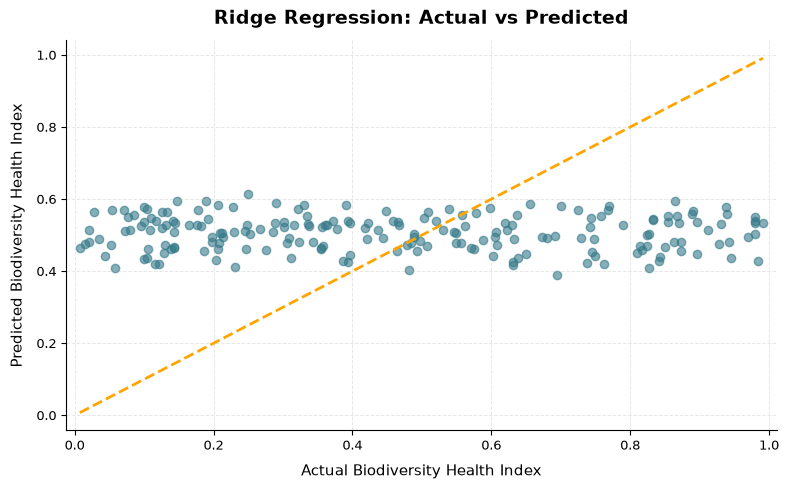

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    y_test,
    y_pred_test,
    color = "#347989",
    alpha=0.6
)

# Perfect prediction line
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color = "orange",
    lw=2
)

style_plot(
    ax,
    title="Ridge Regression: Actual vs Predicted",
    xlabel="Actual Biodiversity Health Index",
    ylabel="Predicted Biodiversity Health Index",
    grid=True
)

plt.tight_layout()
plt.show()